# Baseline Modeller - Route 502

`route_502_features.csv` uzerinde baseline modelleri egitir ve karsilastirir.

**Modeller:**
1. Naive Baseline — GTFS planlanmis sureyi tahmin olarak kullan
2. Historical Average — (from_stop_seq) bazli ortalama
3. Linear Regression
4. Random Forest
5. XGBoost

**Metrikler:** MAE, RMSE, MAPE, R²

> Not: Az veriyle (ornegin 61 satir) sonuclar istatistiksel olarak guvenilir degildir.
> Veri arttikca bu notebook'u yeniden calistirin.

In [1]:
import pandas as pd
import numpy as np
import os
import sys
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('xgboost bulunamadi, XGBoost modeli atlanacak. Kurmak icin: pip install xgboost')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
FEATURES_CSV = os.path.join(PROJECT_ROOT, 'collected_data', 'route_502_features_v2.csv')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

print(f'Features CSV: {os.path.exists(FEATURES_CSV)}')
print(f'Path: {FEATURES_CSV}')

Features CSV: True
Path: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\collected_data\route_502_features_v2.csv


## 1. Veri Yukleme

In [2]:
df = pd.read_csv(FEATURES_CSV)
print(f'Dataset: {len(df)} satir, {len(df.columns)} kolon')
print(f'Hedef degisken (travel_time_min):')
print(f'  min={df["travel_time_min"].min():.2f}, max={df["travel_time_min"].max():.2f}, '
      f'ort={df["travel_time_min"].mean():.2f}, std={df["travel_time_min"].std():.2f}')
df.head()

Dataset: 138282 satir, 32 kolon
Hedef degisken (travel_time_min):
  min=0.43, max=14.98, ort=1.19, std=1.24


,date,bus_id,route_id,yon,trip_start_time,from_stop_seq,to_stop_seq,from_stop_name,to_stop_name,arrival_timestamp,...,prev_deviation,scheduled_travel_min,temperature,humidity,precipitation,wind_speed,visibility,weather_cat_enc,congestion_ratio,travel_time_min
0,2026-04-02,10216,565,1,11:08:16,9,8,Toprak Yol,Lale Tepe Cami,2026-04-02 11:08:50,...,0.0,1.239,18.76,45.0,0.0,35.172,10.0,1.0,1.0,0.567
1,2026-04-02,12144,502,1,11:08:16,25,24,Yasemin,Sağlık Ocağı,2026-04-02 11:08:50,...,0.0,1.149,18.76,45.0,0.0,35.172,10.0,1.0,1.0,0.567
2,2026-04-02,12060,502,0,11:08:16,32,31,Halkapınar Metro,Halkapınar Tramvay,2026-04-02 11:08:50,...,0.0,1.083,18.76,45.0,0.0,35.172,10.0,1.0,1.0,0.567
3,2026-04-02,12064,502,0,11:08:16,10,9,Durmuş Yaşar İlköğretim Okulu,Birkent,2026-04-02 11:08:50,...,0.0,0.841,18.76,45.0,0.0,35.172,10.0,1.0,1.0,0.567
4,2026-04-02,10242,565,1,11:08:16,18,17,Mehmet Akif Cami,Evka 4 Muhtarlık,2026-04-02 11:08:50,...,0.0,0.942,18.76,45.0,0.0,35.172,10.0,1.0,1.0,0.567


## 2. Train/Test Bolme

Zaman serisinde kronolojik bolme yapilir — son %20 test seti.

In [3]:
# Kronolojik siralama (tarih + saat)
df = df.sort_values(['date', 'trip_start_time', 'from_stop_seq']).reset_index(drop=True)

# Son %20 test
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f'Train: {len(train_df)} satir')
print(f'Test:  {len(test_df)} satir')

if len(test_df) < 5:
    print('\nUYARI: Test seti cok kucuk. Sonuclar guvenilir degil.')
    print('Daha fazla veri toplandiktan sonra yeniden calistirin.')

Train: 110625 satir
Test:  27657 satir


In [4]:
# Hedef degisken
TARGET = 'travel_time_min'

# Sayisal ozellikler (v2 kolon adlari)
NUMERIC_FEATURES = [
    'hour', 'day_of_week', 'day_type', 'time_block',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'from_stop_seq', 'to_stop_seq',
    'distance_m', 'stop_progress',
    'prev_travel_time_min', 'prev_deviation',
    'scheduled_travel_min',
    'temperature', 'humidity', 'precipitation', 'wind_speed',
    'visibility', 'weather_cat_enc', 'congestion_ratio',
]

ALL_FEATURES = NUMERIC_FEATURES

# Eksik kolon kontrolu
available = [f for f in ALL_FEATURES if f in train_df.columns and train_df[f].notna().all()]
print(f'Kullanilacak ozellikler ({len(available)}):')
for f in available:
    print(f'  {f}')

X_train = train_df[available].values
y_train = train_df[TARGET].values
X_test = test_df[available].values
y_test = test_df[TARGET].values

Kullanilacak ozellikler (22):
  hour
  day_of_week
  day_type
  time_block
  hour_sin
  hour_cos
  dow_sin
  dow_cos
  from_stop_seq
  to_stop_seq
  distance_m
  stop_progress
  prev_travel_time_min
  prev_deviation
  scheduled_travel_min
  temperature
  humidity
  precipitation
  wind_speed
  visibility
  weather_cat_enc
  congestion_ratio


## 3. Metrik Hesaplama Fonksiyonu

In [5]:
def evaluate(y_true, y_pred, model_name):
    """Model performans metriklerini hesapla."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # MAPE: sifir degerler icin koruma
    mask = y_true > 0.01
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    
    return {
        'model': model_name,
        'MAE (dk)': round(mae, 4),
        'RMSE (dk)': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
        'R2': round(r2, 4),
    }

## 4. Model Egitimi

In [6]:
results = []

# --- Model 1: Naive Baseline (GTFS scheduled) ---
y_pred_naive = test_df['scheduled_travel_min'].values
results.append(evaluate(y_test, y_pred_naive, 'Naive (GTFS Scheduled)'))
print(f"1. Naive Baseline: MAE = {results[-1]['MAE (dk)']:.4f} dk")

1. Naive Baseline: MAE = 0.6125 dk


In [7]:
# --- Model 2: Historical Average ---
# (from_stop_seq) bazli ortalama — egitim setinden hesapla, test setine uygula
hist_avg = train_df.groupby('from_stop_seq')[TARGET].mean()
global_avg = train_df[TARGET].mean()

y_pred_hist = test_df['from_stop_seq'].map(hist_avg).fillna(global_avg).values
results.append(evaluate(y_test, y_pred_hist, 'Historical Average'))
print(f"2. Historical Average: MAE = {results[-1]['MAE (dk)']:.4f} dk")

2. Historical Average: MAE = 0.5662 dk


In [8]:
# --- Model 3: Linear Regression ---
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr = np.clip(y_pred_lr, 0, None)  # Negatif tahmin engelle
results.append(evaluate(y_test, y_pred_lr, 'Linear Regression'))
print(f"3. Linear Regression: MAE = {results[-1]['MAE (dk)']:.4f} dk")

3. Linear Regression: MAE = 0.5933 dk


In [9]:
# --- Model 4: Random Forest ---
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
results.append(evaluate(y_test, y_pred_rf, 'Random Forest'))
print(f"4. Random Forest: MAE = {results[-1]['MAE (dk)']:.4f} dk")

4. Random Forest: MAE = 0.4695 dk


In [10]:
# --- Model 5: XGBoost ---
if HAS_XGB:
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        min_child_weight=3,
        random_state=42,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)
    results.append(evaluate(y_test, y_pred_xgb, 'XGBoost'))
    print(f"5. XGBoost: MAE = {results[-1]['MAE (dk)']:.4f} dk")
else:
    print('5. XGBoost atlandi (kurmak icin: pip install xgboost)')

5. XGBoost: MAE = 0.4784 dk


## 5. Sonuclari Karsilastir

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAE (dk)')

print('='*65)
print('MODEL KARSILASTIRMASI')
print('='*65)
print(results_df.to_string(index=False))
print('='*65)

best = results_df.iloc[0]
print(f'\nEn iyi model: {best["model"]}')
print(f'  MAE:  {best["MAE (dk)"]:.4f} dk')
print(f'  MAPE: {best["MAPE (%)"]:.2f}%')
print(f'  R²:   {best["R2"]:.4f}')

print(f'\nMakale referansi (Istanbul, Hibrit LSTM):')
print(f'  MAE:  2.97 dk')
print(f'  MAPE: 14.79%')
print(f'  R²:   0.9272')

if len(test_df) < 20:
    print(f'\n** UYARI: Test seti sadece {len(test_df)} satir. '
          f'Sonuclar istatistiksel olarak guvenilir degil. **')

MODEL KARSILASTIRMASI
                 model  MAE (dk)  RMSE (dk)  MAPE (%)      R2
         Random Forest    0.4695     0.8731     50.22  0.3325
               XGBoost    0.4784     0.8819     52.15  0.3191
    Historical Average    0.5662     0.9922     62.50  0.1379
     Linear Regression    0.5933     1.0597     64.33  0.0167
Naive (GTFS Scheduled)    0.6125     1.0935     64.99 -0.0470

En iyi model: Random Forest
  MAE:  0.4695 dk
  MAPE: 50.22%
  R²:   0.3325

Makale referansi (Istanbul, Hibrit LSTM):
  MAE:  2.97 dk
  MAPE: 14.79%
  R²:   0.9272


In [12]:
# Sonuclari CSV'ye kaydet
os.makedirs(os.path.join(RESULTS_DIR, 'tables'), exist_ok=True)
results_csv = os.path.join(RESULTS_DIR, 'tables', 'baseline_results.csv')
results_df.to_csv(results_csv, index=False)
print(f'Kaydedildi: {results_csv}')

Kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\tables\baseline_results.csv


## 6. Feature Importance (Random Forest)

In [13]:
importances = pd.Series(rf.feature_importances_, index=available)
importances = importances.sort_values(ascending=False)

print('Feature Importance (Random Forest):')
for feat, imp in importances.items():
    bar = '#' * int(imp * 50)
    print(f'  {feat:30s} {imp:.4f}  {bar}')

Feature Importance (Random Forest):
  scheduled_travel_min           0.3275  ################
  distance_m                     0.1908  #########
  stop_progress                  0.0780  ###
  to_stop_seq                    0.0733  ###
  prev_travel_time_min           0.0712  ###
  from_stop_seq                  0.0641  ###
  prev_deviation                 0.0486  ##
  hour_cos                       0.0234  #
  hour                           0.0230  #
  humidity                       0.0204  #
  temperature                    0.0179  
  wind_speed                     0.0162  
  hour_sin                       0.0126  
  dow_sin                        0.0083  
  time_block                     0.0082  
  day_of_week                    0.0069  
  dow_cos                        0.0026  
  precipitation                  0.0022  
  visibility                     0.0018  
  weather_cat_enc                0.0018  
  day_type                       0.0012  
  congestion_ratio               0.0000 

## 7. Gorsellestirmeler

In [14]:
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ImportError:
    HAS_PLT = False
    print('matplotlib bulunamadi')

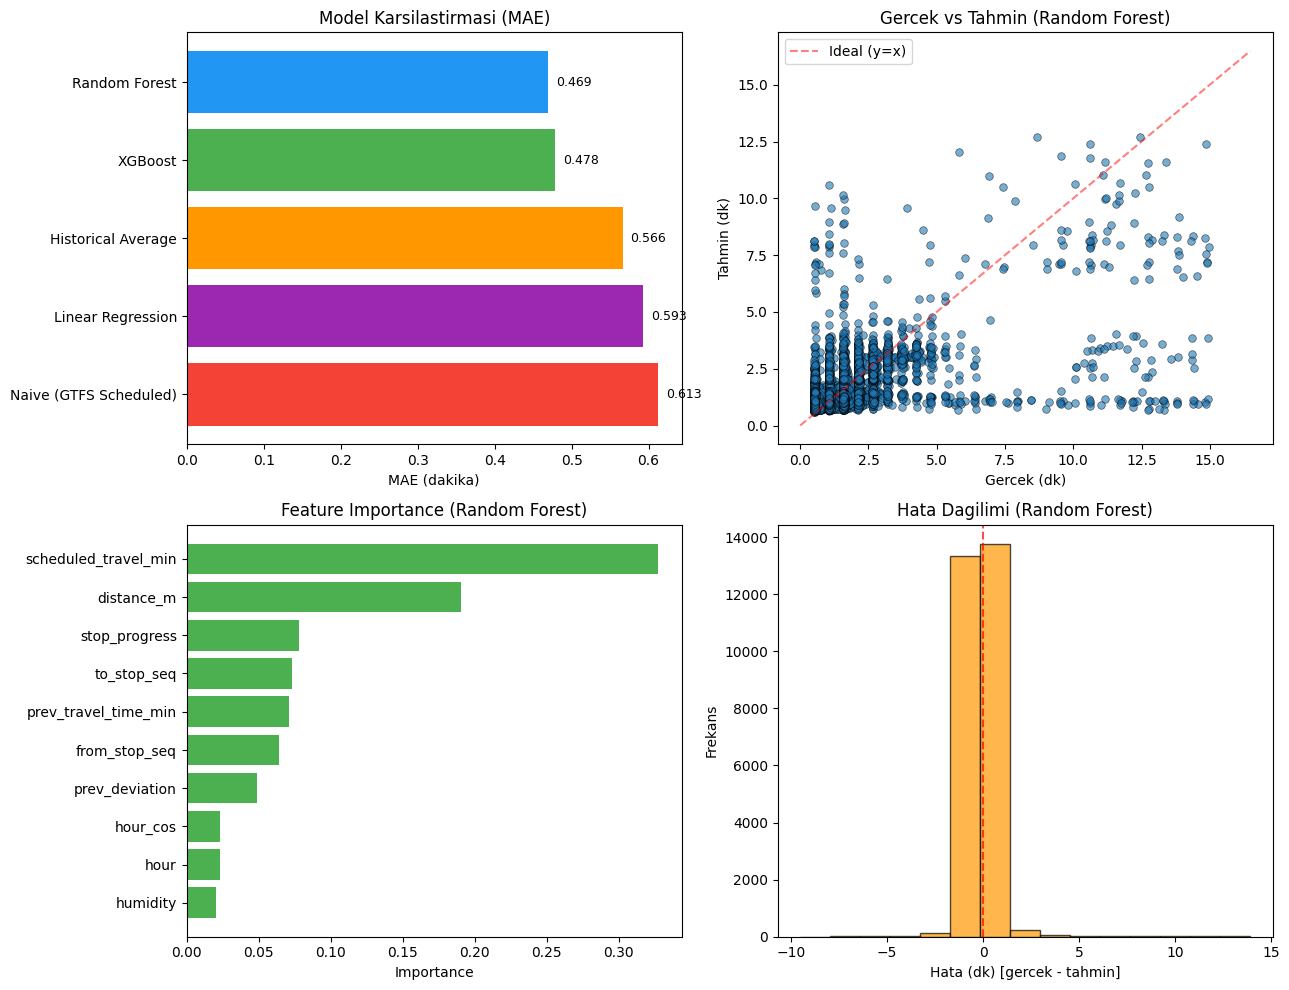

Gorsel kaydedildi: c:\Users\Bilal\Desktop\Dersler\CSE496-Graduation-Project\results\figures\baseline_comparison.png


In [15]:
if HAS_PLT:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    
    # 1. MAE karsilastirmasi
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
    axes[0, 0].barh(results_df['model'], results_df['MAE (dk)'],
                    color=colors[:len(results_df)])
    axes[0, 0].set_xlabel('MAE (dakika)')
    axes[0, 0].set_title('Model Karsilastirmasi (MAE)')
    axes[0, 0].invert_yaxis()
    for i, v in enumerate(results_df['MAE (dk)']):
        axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)
    
    # 2. Gercek vs Tahmin (en iyi model)
    best_name = results_df.iloc[0]['model']
    if best_name == 'Random Forest':
        y_pred_best = y_pred_rf
    elif best_name == 'XGBoost' and HAS_XGB:
        y_pred_best = y_pred_xgb
    elif best_name == 'Linear Regression':
        y_pred_best = y_pred_lr
    elif best_name == 'Historical Average':
        y_pred_best = y_pred_hist
    else:
        y_pred_best = y_pred_naive
    
    axes[0, 1].scatter(y_test, y_pred_best, alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
    lim = max(y_test.max(), y_pred_best.max()) * 1.1
    axes[0, 1].plot([0, lim], [0, lim], 'r--', alpha=0.5, label='Ideal (y=x)')
    axes[0, 1].set_xlabel('Gercek (dk)')
    axes[0, 1].set_ylabel('Tahmin (dk)')
    axes[0, 1].set_title(f'Gercek vs Tahmin ({best_name})')
    axes[0, 1].legend()
    
    # 3. Feature Importance
    top_features = importances.head(10)
    axes[1, 0].barh(top_features.index, top_features.values, color='#4CAF50')
    axes[1, 0].set_xlabel('Importance')
    axes[1, 0].set_title('Feature Importance (Random Forest)')
    axes[1, 0].invert_yaxis()
    
    # 4. Hata dagilimi (en iyi model)
    errors = y_test - y_pred_best
    axes[1, 1].hist(errors, bins=15, edgecolor='black', alpha=0.7, color='#FF9800')
    axes[1, 1].axvline(0, color='red', linestyle='--', alpha=0.7)
    axes[1, 1].set_xlabel('Hata (dk) [gercek - tahmin]')
    axes[1, 1].set_ylabel('Frekans')
    axes[1, 1].set_title(f'Hata Dagilimi ({best_name})')
    
    plt.tight_layout()
    
    os.makedirs(os.path.join(RESULTS_DIR, 'figures'), exist_ok=True)
    fig_path = os.path.join(RESULTS_DIR, 'figures', 'baseline_comparison.png')
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Gorsel kaydedildi: {fig_path}')

## 8. Naive vs Scheduled Analiz

Planlanmis sureyi feature olarak kullanmanin ne kadar faydali oldugunu gostermek icin
scheduled_travel_minutes olmadan model egitelim ve karsilastiralim.

In [16]:
# scheduled olmadan ozellik seti
features_no_sched = [f for f in available if 'scheduled' not in f]
X_train_ns = train_df[features_no_sched].values
X_test_ns = test_df[features_no_sched].values

rf_no_sched = RandomForestRegressor(
    n_estimators=100, max_depth=10, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf_no_sched.fit(X_train_ns, y_train)
y_pred_ns = rf_no_sched.predict(X_test_ns)

res_with = evaluate(y_test, y_pred_rf, 'RF (scheduled ile)')
res_without = evaluate(y_test, y_pred_ns, 'RF (scheduled olmadan)')

print('Scheduled feature etkisi:')
print(f'  RF + scheduled:  MAE = {res_with["MAE (dk)"]:.4f} dk')
print(f'  RF - scheduled:  MAE = {res_without["MAE (dk)"]:.4f} dk')
diff = res_without['MAE (dk)'] - res_with['MAE (dk)']
print(f'  Fark: {diff:+.4f} dk ({"scheduled faydali" if diff > 0 else "scheduled etkisiz"})')
print(f'\nBu analiz, makaleye ozgun katkimizi kanitlar.')

Scheduled feature etkisi:
  RF + scheduled:  MAE = 0.4695 dk
  RF - scheduled:  MAE = 0.4746 dk
  Fark: +0.0051 dk (scheduled faydali)

Bu analiz, makaleye ozgun katkimizi kanitlar.


## Sonuc

| Cikti | Dosya |
|-------|-------|
| Karsilastirma tablosu | `results/tables/baseline_results.csv` |
| Gorseller | `results/figures/baseline_comparison.png` |

Sonraki adim: `deep_learning.ipynb` ile LSTM modeli egitimi.

**Onemli:** Veri arttikca bu notebook'u tekrar calistirin.
1 haftalik veri ile sonuclar cok daha anlamli olacaktir.